# PaluScope — Phase 0 — 03 Détection de régions candidates
**Responsable : Membre 3 · Bloc D** (vision classique, sans CNN)

**But.** Partir d'une image de frottis et obtenir une liste de *régions candidates* : des petites zones qui pourraient être des parasites.
On ne dit **pas** « c'est un parasite » : on dit « ça mérite d'être regardé ». La décision viendra en Phase 2.

**Pipeline** (celui de la feuille de route) :
`Image → Gris/HSV → Seuillage → Morphologie → Composantes connexes → Contours → Mesures → Candidats`

**Idée de départ.** À ×1000, un parasite est une *petite tache sombre* sur un fond plus clair. Les grosses taches bleu foncé sont des globules blancs : ce ne sont pas des candidats (trop grosses).

Le code réutilisable est dans `src/candidates/` et `src/preprocessing/`. Ici on explique, on visualise, on règle.

In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Le notebook est dans notebooks/phase_0/ : on remonte à la racine du dépôt pour importer src/
ROOT = Path("../..").resolve()
sys.path.insert(0, str(ROOT))

from src.preprocessing.color import to_gray, to_hsv
from src.candidates.extract import CandidateParams, extract_candidates, run_pipeline_steps
from src.candidates.visualize import draw_candidates
from src.candidates.evaluate import parse_boxes, clip_boxes, match_candidates

RAW_DIR = ROOT / "data" / "raw"           # dataset dézippé ici (non versionné)
assert RAW_DIR.exists() and any(RAW_DIR.rglob("*.jpg")), f"Pas d'images dans {RAW_DIR}"
images = sorted(RAW_DIR.rglob("*.jpg"))
ann_by_stem = {p.stem: p for p in RAW_DIR.rglob("*.xml")}
random.seed(42)
print(len(images), "images ;", len(ann_by_stem), "annotations")

def load_rgb(path):
    # PIL charge en RGB. (cv2.imread charge en BGR : piège classique !)
    return np.array(Image.open(path).convert("RGB"))

def load_gt(path, shape):
    p = ann_by_stem.get(path.stem)
    return clip_boxes(parse_boxes(p), shape[1], shape[0]) if p else []

1182 images ; 1182 annotations


## 0. Une image, c'est un tableau de nombres
Une image couleur = un tableau NumPy de forme `(hauteur, largeur, 3)` : 3 canaux R, G, B, chacun entre 0 (noir) et 255 (maximum).
Un niveau de gris = un seul canal. Regarde `shape` et `dtype`.

plasmodium-phone-0001.jpg (750, 750, 3) uint8 | pixel (0,0) = [138 118 117] | parasites annotés : 6


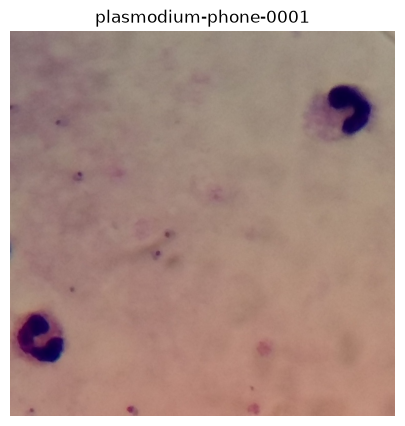

In [2]:
path = images[0]            # change l'indice pour tester d'autres images
img = load_rgb(path)
gt = load_gt(path, img.shape)
print(path.name, img.shape, img.dtype, "| pixel (0,0) =", img[0, 0], "| parasites annotés :", len(gt))
plt.figure(figsize=(5, 5)); plt.imshow(img); plt.axis("off"); plt.title(path.stem); plt.show()

## 1. Gris, canal vert, HSV
- **Gris** : moyenne pondérée de R, G, B (l'œil est plus sensible au vert).
- **Canal vert** : le violet des parasites *absorbe* le vert, donc il y est souvent plus contrasté.
- **HSV** : Teinte (la couleur), Saturation (à quel point elle est vive), Valeur (la luminosité). Utile pour séparer « sombre » de « coloré ».

Compare visuellement : où le parasite ressort-il le mieux ?

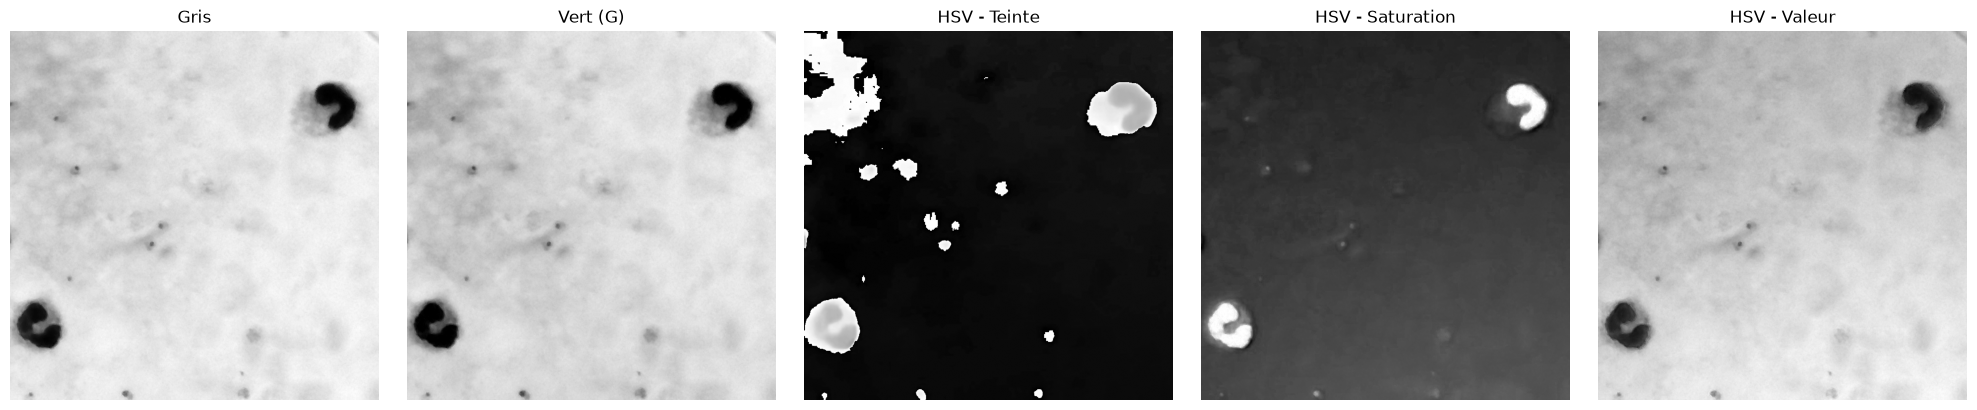

In [3]:
hsv = to_hsv(img)
views = [("Gris", to_gray(img)), ("Vert (G)", img[:, :, 1]),
         ("HSV - Teinte", hsv[:, :, 0]), ("HSV - Saturation", hsv[:, :, 1]), ("HSV - Valeur", hsv[:, :, 2])]
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, (t, v) in zip(ax, views):
    a.imshow(v, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 2. Carte de « sombreur locale » (black-hat)
Problème : chaque frottis a sa teinte (rosé, violet, bleuté). Un seuil unique sur l'image brute ne marcherait pas.
**Black-hat** = *fermeture(image) − image*. La fermeture « efface » les petites taches sombres en les remplaçant par le fond voisin ; la différence ne garde que ces taches.
Résultat : une image presque noire, avec des points lumineux là où il y avait de petites taches sombres.
Le paramètre `blackhat_ksize` doit être **plus grand que les taches à détecter**.

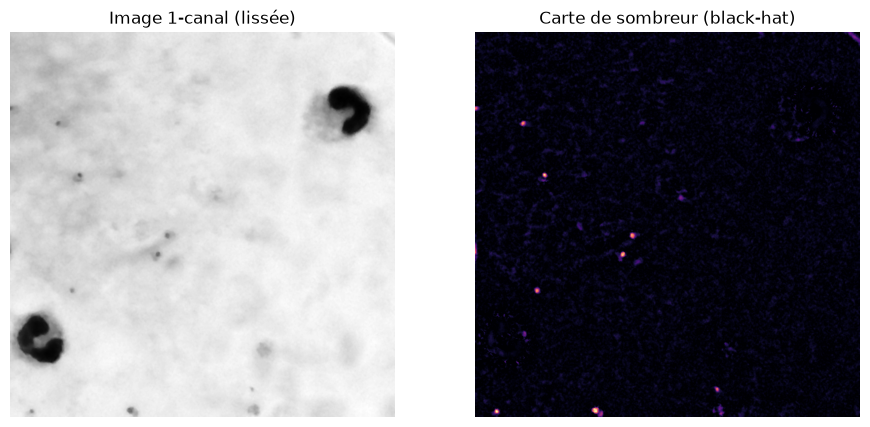

In [4]:
steps = run_pipeline_steps(img)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(steps["channel"], cmap="gray"); ax[0].set_title("Image 1-canal (lissée)")
ax[1].imshow(steps["darkness"], cmap="magma"); ax[1].set_title("Carte de sombreur (black-hat)")
for a in ax: a.axis("off")
plt.show()

## 3. Seuillage
Seuiller = décider pixel par pixel : « sombre » (blanc) ou « pas sombre » (noir). Résultat : un **masque binaire**.
On utilise la méthode d'Otsu (seuil choisi automatiquement pour séparer deux groupes de valeurs), avec un **plancher** `min_contrast` pour ne pas détecter du bruit sur une image sans rien de sombre.

Seuil utilisé : 20.0


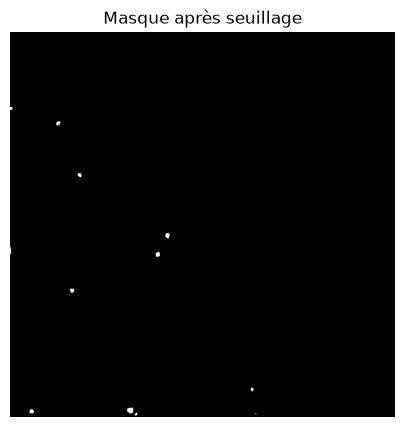

In [5]:
print("Seuil utilisé :", steps["threshold"])
plt.figure(figsize=(5, 5)); plt.imshow(steps["raw_mask"], cmap="gray"); plt.title("Masque après seuillage"); plt.axis("off"); plt.show()

## 4. Morphologie mathématique
Deux opérations sur le masque, avec un petit élément structurant (ici un disque de 3 px) :
- **Ouverture** (érosion puis dilatation) : supprime les pixels isolés (bruit).
- **Fermeture** (dilatation puis érosion) : rebouche les petits trous dans une tache.

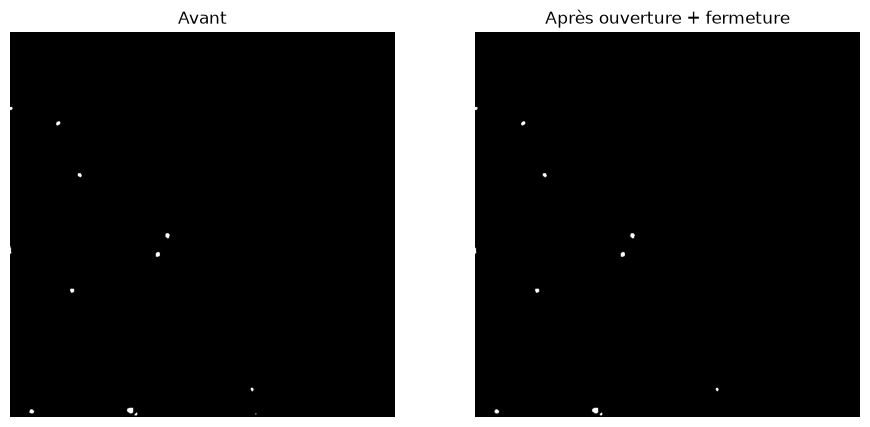

Pixels blancs avant / après : 559 / 544


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(steps["raw_mask"], cmap="gray"); ax[0].set_title("Avant")
ax[1].imshow(steps["clean_mask"], cmap="gray"); ax[1].set_title("Après ouverture + fermeture")
for a in ax: a.axis("off")
plt.show()
print("Pixels blancs avant / après :", int((steps["raw_mask"] > 0).sum()), "/", int((steps["clean_mask"] > 0).sum()))

## 5. Composantes connexes, contours, mesures
- **Composante connexe** : un groupe de pixels blancs *collés les uns aux autres* (connectivité 8 : voisins horizontaux, verticaux et diagonaux). Chaque tache du masque en est une.
- **Contour** : la ligne qui entoure une composante.
- **Aire A** = nombre de pixels de la composante. **Périmètre P** = longueur du contour.
- **Circularité** = 4πA / P². Pour un disque parfait elle vaut 1 ; plus la forme est allongée ou découpée, plus elle tend vers 0.
  *Vérification :* disque de rayon r → A = πr², P = 2πr → 4π·πr² / (2πr)² = 1.

In [7]:
cands = steps["candidates"]
df = pd.DataFrame([{k: v for k, v in c.items() if k != "bbox"} | {"x": c["bbox"][0], "y": c["bbox"][1],
                                                                "w": c["bbox"][2], "h": c["bbox"][3]} for c in cands])
print(len(cands), "candidats")
display(df.describe().T if len(df) else "aucun candidat")

11 candidats


,count,mean,std,min,25%,50%,75%,max
id,11.0,5.000000,3.316625,0.000000,2.500000,5.000000,7.500000,10.000000
area,11.0,49.454545,25.625626,21.000000,27.500000,49.000000,60.000000,109.000000
perimeter,11.0,23.611170,6.030374,14.485281,20.606602,23.656854,26.020815,36.142135
circularity,11.0,0.956040,0.145797,0.516445,1.000000,1.000000,1.000000,1.000000
x,11.0,173.000000,146.387158,0.000000,64.000000,132.000000,263.500000,469.000000
y,11.0,476.000000,224.389839,146.000000,333.500000,428.000000,712.500000,741.000000
w,11.0,7.363636,2.460599,3.000000,5.500000,8.000000,8.500000,12.000000
h,11.0,8.545455,1.967925,6.000000,7.500000,8.000000,10.000000,12.000000


## 6. Résultat sur l'image
Rouge = nos candidats ; vert = parasites annotés (vérité terrain).
Ce qu'on veut : **chaque boîte verte contient un candidat rouge**. Avoir des rouges en trop est acceptable à ce stade.

{'n_gt': 6, 'n_found': 6, 'n_candidates': 11, 'n_false_candidates': 4}


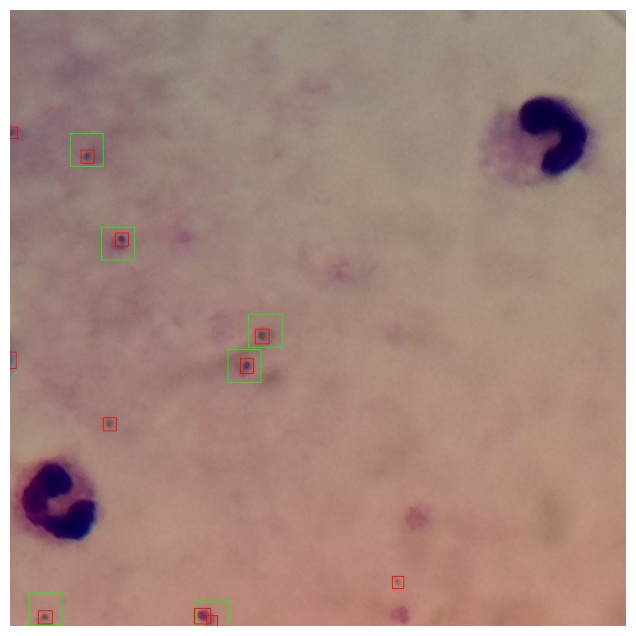

In [8]:
res = match_candidates(cands, gt)
print(res)
plt.figure(figsize=(8, 8)); plt.imshow(draw_candidates(img, cands, gt)); plt.axis("off"); plt.show()

## 7. Calibrer à partir des vrais parasites
La note de synthèse (Membre 1) rappelle que les boîtes annotées font ~40×40 px quelle que soit la taille réelle du parasite : **on ne s'en sert pas pour régler les filtres de taille.**
À la place, on regarde les candidats *qui tombent dans une boîte annotée* (ce sont de vrais parasites) et on observe leur aire et leur circularité. Puis on règle `min_area`, `max_area`, `min_circularity` pour les garder tous.
Pour cela on relâche d'abord les filtres au maximum.

                   count       mean        std  min   25%   50%   75%    max
is_parasite_zone                                                            
False             1882.0  51.509033  62.574928  3.0  16.0  35.0  65.0  556.0
True              1073.0  66.256291  29.855818  5.0  47.0  66.0  83.0  197.0


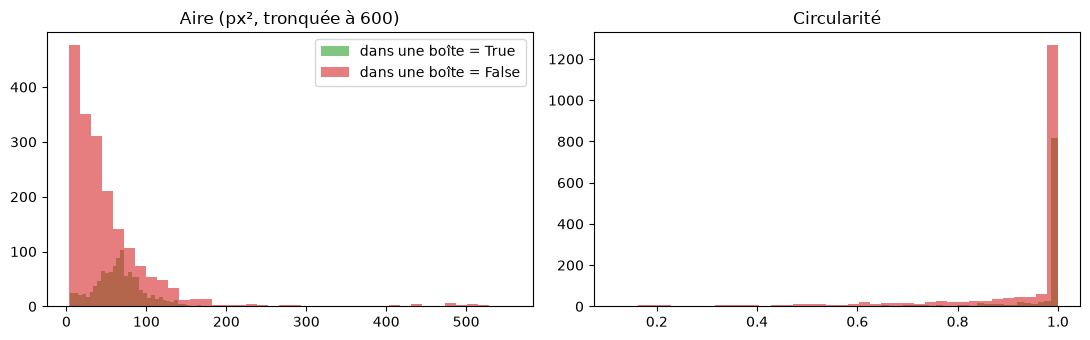

In [2]:
loose = CandidateParams(min_area=1, max_area=5000, min_circularity=0.0)
sample = random.sample(images, 150)
rows = []
for p in sample:
    im = load_rgb(p); g = load_gt(p, im.shape)
    for c in extract_candidates(im, loose):
        x, y, w, h = c["bbox"]; cx, cy = x + w / 2, y + h / 2
        inside = any(b["xmin"] <= cx <= b["xmax"] and b["ymin"] <= cy <= b["ymax"] for b in g)
        rows.append({"area": c["area"], "circ": c["circularity"], "is_parasite_zone": inside})
dfc = pd.DataFrame(rows)
print(dfc.groupby("is_parasite_zone").area.describe())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for flag, col in [(True, "tab:green"), (False, "tab:red")]:
    s = dfc[dfc.is_parasite_zone == flag]
    ax[0].hist(s.area.clip(upper=600), bins=40, alpha=.6, color=col, label=f"dans une boîte = {flag}")
    ax[1].hist(s.circ, bins=40, alpha=.6, color=col)
ax[0].set_title("Aire (px², tronquée à 600)"); ax[0].legend(); ax[1].set_title("Circularité")
plt.tight_layout(); plt.show()

## 8. Mesurer : rappel et candidats en trop
Sur un échantillon d'images, pour une configuration de paramètres :
- **rappel** = parasites annotés ayant au moins un candidat dans leur boîte (à maximiser : un parasite manqué est perdu pour toujours) ;
- **candidats par image** (à garder raisonnable) ;
- **candidats sur les images SANS parasite** : mesure directe des faux positifs (cf. note de synthèse : 234 images négatives).

In [3]:
def evaluate(params, paths):
    tot = dict(n_gt=0, n_found=0, n_candidates=0, n_false_candidates=0, neg_cands=0, neg_imgs=0)
    for p in paths:
        im = load_rgb(p); g = load_gt(p, im.shape)
        c = extract_candidates(im, params)
        r = match_candidates(c, g)
        for k in ("n_gt", "n_found", "n_candidates", "n_false_candidates"): tot[k] += r[k]
        if not g: tot["neg_cands"] += len(c); tot["neg_imgs"] += 1
    return {"rappel": tot["n_found"] / max(1, tot["n_gt"]),
            "candidats/image": tot["n_candidates"] / len(paths),
            "candidats/image négative": tot["neg_cands"] / max(1, tot["neg_imgs"])}

eval_paths = random.sample(images, 150)
configs = {
    "défaut actuel":        CandidateParams(),
    "canal vert":           CandidateParams(channel="green"),
    "contraste min 12":     CandidateParams(min_contrast=12, min_area=6, max_area=400),
    "contraste min 30":     CandidateParams(min_contrast=30),
    "black-hat 9":          CandidateParams(blackhat_ksize=9),
    "black-hat 21":         CandidateParams(blackhat_ksize=21),
}
table = pd.DataFrame({name: evaluate(p, eval_paths) for name, p in configs.items()}).T
display(table.round(2))

,rappel,candidats/image,candidats/image négative
défaut actuel,0.99,17.86,6.35
canal vert,0.97,19.02,7.27
contraste min 12,1.00,38.47,17.19
contraste min 30,0.93,11.29,3.38
black-hat 9,0.85,9.43,2.69
black-hat 21,0.85,21.98,9.58


## 9. Regarder les erreurs
Les chiffres ne suffisent pas : on regarde. Ci-dessous, 6 images au hasard avec la configuration choisie.
Note ce que tu vois (parasites manqués ? quel type de faux candidats : débris, bords, globules blancs ?) — c'est la matière de ta section « limites » du rapport.

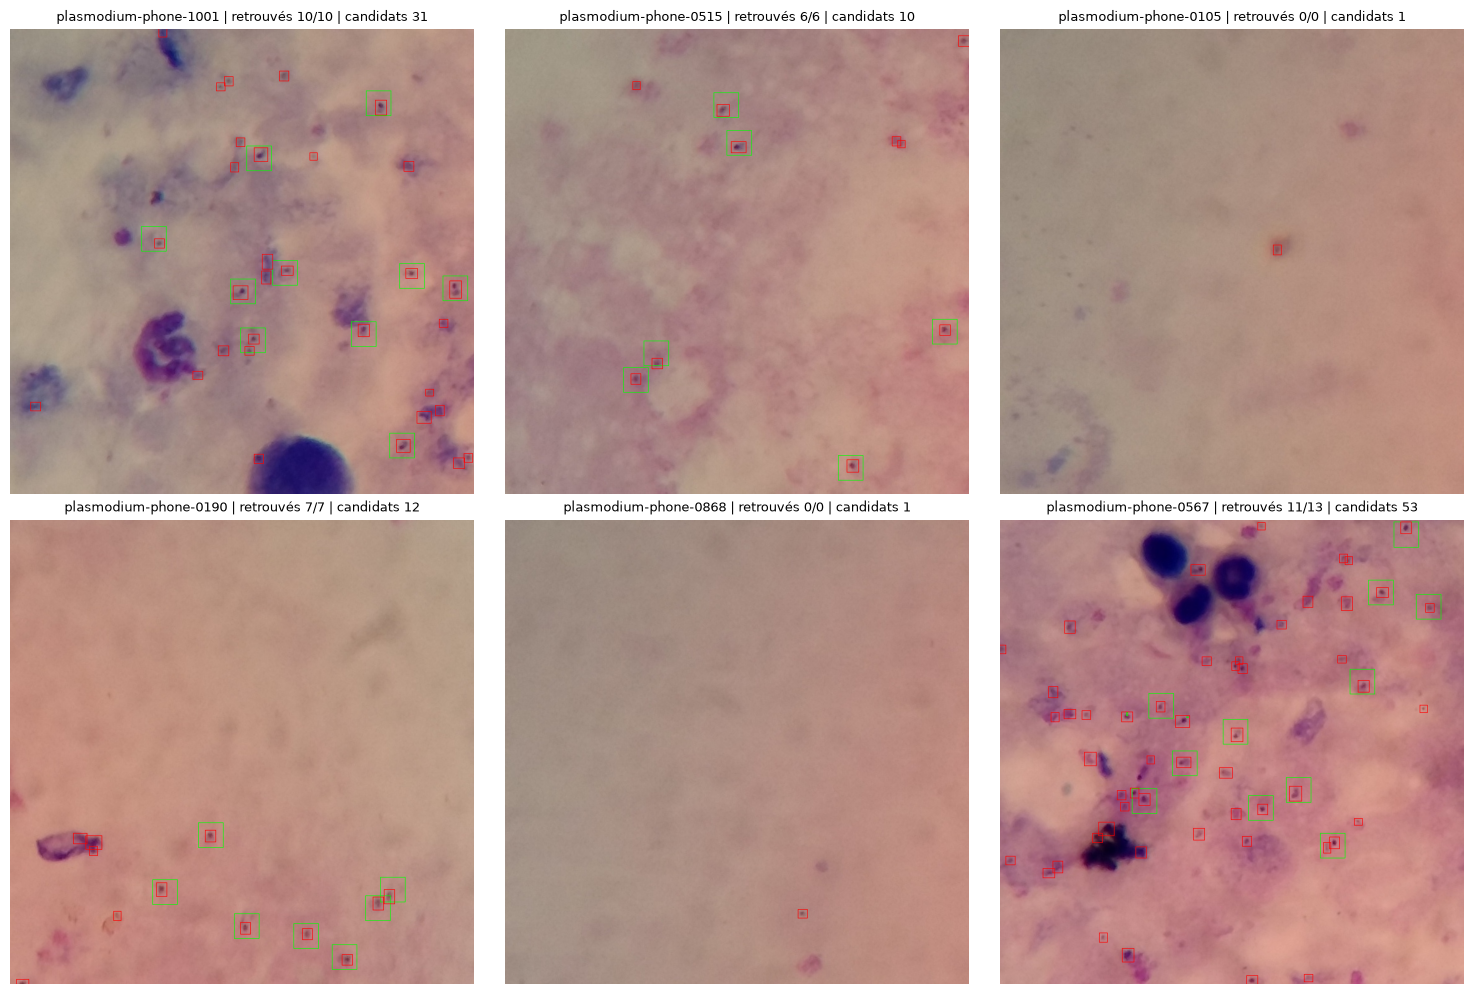

In [11]:
BEST = CandidateParams()   # <- remplace par la configuration que tu retiens
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, p in zip(axes.ravel(), random.sample(images, 6)):
    im = load_rgb(p); g = load_gt(p, im.shape); c = extract_candidates(im, BEST)
    ax.imshow(draw_candidates(im, c, g)); ax.axis("off")
    r = match_candidates(c, g); ax.set_title(f"{p.stem} | retrouvés {r['n_found']}/{r['n_gt']} | candidats {r['n_candidates']}", fontsize=9)
plt.tight_layout(); plt.show()